### 1. Import Preprocessed dataset

In [3]:
import pandas as pd

file_path = "../Dataset/prepared/final_preprocessed_6PCs.csv"
df = pd.read_csv(file_path)

# Optional: Preview the first few rows
df.head()

,FP_IDX,FP_AMP1,FP_AMP2,CIR_PWR,MAX_NOISE,RXPACC,FRAME_LEN,CIR_PC1,CIR_PC2,CIR_PC3,CIR_PC4,CIR_PC5,CIR_PC6,RANGE
0,745.0,18712.0,10250.0,11855.0,967.0,611.0,39.0,-9.034594,21.247168,-2.683200,-12.696969,-3.976131,2.563186,3.90
1,749.0,11239.0,6313.0,18968.0,1133.0,447.0,27.0,25.389144,-55.417879,-34.631625,-20.236273,0.880668,2.820708,0.66
2,746.0,4355.0,5240.0,14699.0,894.0,723.0,27.0,-19.931322,-18.167155,-8.725183,-10.258672,-3.037045,-0.307628,7.86
3,750.0,8502.0,8416.0,8748.0,1127.0,1024.0,39.0,-38.491470,-15.676134,-2.714543,-1.786545,-2.430648,-1.966675,3.48
4,746.0,17845.0,18095.0,11380.0,1744.0,276.0,27.0,58.915081,55.849609,15.308050,-8.927246,-2.424918,-22.160805,1.19


### 2. Check feature linearity

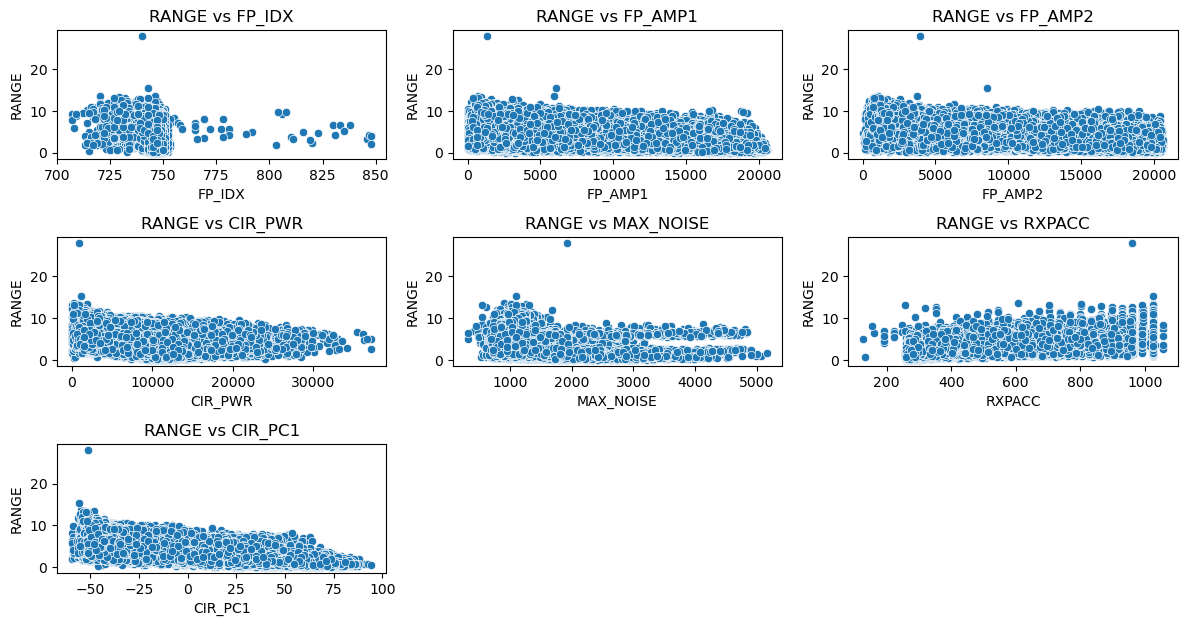

RANGE        1.000000
RXPACC       0.626349
CIR_PC3      0.064315
CIR_PC6      0.020893
CIR_PC5      0.002252
CIR_PC4     -0.047454
FRAME_LEN   -0.048082
CIR_PC2     -0.063041
MAX_NOISE   -0.260065
CIR_PWR     -0.263718
FP_IDX      -0.321809
FP_AMP1     -0.459196
FP_AMP2     -0.479689
CIR_PC1     -0.655803
Name: RANGE, dtype: float64


In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming df is your dataset
features = ["FP_IDX", "FP_AMP1", "FP_AMP2", "CIR_PWR", "MAX_NOISE", "RXPACC","CIR_PC1"]

plt.figure(figsize=(12, 8))
for i, feature in enumerate(features):
    plt.subplot(4, 3, i+1)
    sns.scatterplot(x=df[feature], y=df["RANGE"])
    plt.xlabel(feature)
    plt.ylabel("RANGE")
    plt.title(f"RANGE vs {feature}")

plt.tight_layout()
plt.show()

correlation_matrix = df.corr()
print(correlation_matrix["RANGE"].sort_values(ascending=False))

### 3. Create X and Y, split them into training and testing sets with 70:30 split

In [5]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=["RANGE"])
y = df["RANGE"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=111)
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")

X_train shape: (29400, 13)
X_test shape: (12600, 13)


### 4. Train 4 models and run predictions. Evaluate them using the 4 metrics. 
The 4 models are Linear Regression, Decision Tree Regressor, Multilayer Perceptron Regressor and K-Nearest Neighbour Regressor

In [6]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import matplotlib.pyplot as plt
import numpy as np

# LINEAR REGRESSION
linreg = LinearRegression()
linreg.fit(X_train, y_train)

y_pred = linreg.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mse)

print("Linear Regression Performance on Test Set:")
print(f"Mean Absolute Error: {mae:.4f}")
print(f"Mean Squared Error: {mse:.4f}")
print(f"Root Mean Squared Error: {rmse:.4f}")
print(f"R-squared: {r2:.4f}")


# DECISION TREE REGRESSION
dt_reg = DecisionTreeRegressor(random_state=111)
dt_reg.fit(X_train, y_train)

y_pred_dt = dt_reg.predict(X_test)

mae_dt = mean_absolute_error(y_test, y_pred_dt)
mse_dt = mean_squared_error(y_test, y_pred_dt)
r2_dt = r2_score(y_test, y_pred_dt)
rmse_dt = np.sqrt(mse_dt)
print("\nDecision Tree Regression Performance on Test Set:")
print(f"Mean Absolute Error: {mae_dt:.4f}")
print(f"Mean Squared Error: {mse_dt:.4f}")
print(f"Root Mean Squared Error: {rmse_dt:.4f}")
print(f"R-squared: {r2_dt:.4f}")

# MULTILAYER PERCEPTRON REGRESSION
# Using one hidden layer with 100 neurons and allow up to 500 iterations.
nn_reg = MLPRegressor(hidden_layer_sizes=(100,), max_iter=500, random_state=111)
nn_reg.fit(X_train, y_train)

y_pred_nn = nn_reg.predict(X_test)

mae_nn = mean_absolute_error(y_test, y_pred_nn)
mse_nn = mean_squared_error(y_test, y_pred_nn)
r2_nn = r2_score(y_test, y_pred_nn)
rmse_nn = np.sqrt(mse_nn)

print("\nMLP Regression Performance on Test Set:")
print(f"Mean Absolute Error: {mae_nn:.4f}")
print(f"Mean Squared Error: {mse_nn:.4f}")
print(f"Root Mean Squared Error: {rmse_nn:.4f}")
print(f"R-squared: {r2_nn:.4f}")

# K-NEAREST NEIGHBORS REGRESSION
knn_reg = KNeighborsRegressor(n_neighbors=20, metric='minkowski', p=2)
knn_reg.fit(X_train, y_train)

y_pred_knn = knn_reg.predict(X_test)

mae_knn = mean_absolute_error(y_test, y_pred_knn)
mse_knn = mean_squared_error(y_test, y_pred_knn)
r2_knn = r2_score(y_test, y_pred_knn)
rmse = np.sqrt(mse_knn)

print("\nKNN Regression Performance on Test Set:")
print(f"Mean Absolute Error: {mae_knn:.4f}")
print(f"Mean Squared Error: {mse_knn:.4f}")
print(f"Root Mean Squared Error: {rmse:.4f}")
print(f"R-squared: {r2_knn:.4f}")


Linear Regression Performance on Test Set:
Mean Absolute Error: 1.3372
Mean Squared Error: 2.9438
Root Mean Squared Error: 1.7157
R-squared: 0.4713

Decision Tree Regression Performance on Test Set:
Mean Absolute Error: 1.5595
Mean Squared Error: 4.5557
Root Mean Squared Error: 2.1344
R-squared: 0.1818

MLP Regression Performance on Test Set:
Mean Absolute Error: 7.1392
Mean Squared Error: 69.0307
Root Mean Squared Error: 8.3085
R-squared: -11.3976

KNN Regression Performance on Test Set:
Mean Absolute Error: 1.4298
Mean Squared Error: 3.3794
Root Mean Squared Error: 1.8383
R-squared: 0.3931


### 5. Determining the best K value for KNN Regressor above

k = 1 => CV Mean Squared Error: 5.9460
k = 5 => CV Mean Squared Error: 3.7055
k = 6 => CV Mean Squared Error: 3.6118
k = 7 => CV Mean Squared Error: 3.5485
k = 8 => CV Mean Squared Error: 3.5082
k = 10 => CV Mean Squared Error: 3.4488
k = 15 => CV Mean Squared Error: 3.3958
k = 20 => CV Mean Squared Error: 3.3748
k = 25 => CV Mean Squared Error: 3.3714
k = 30 => CV Mean Squared Error: 3.3670


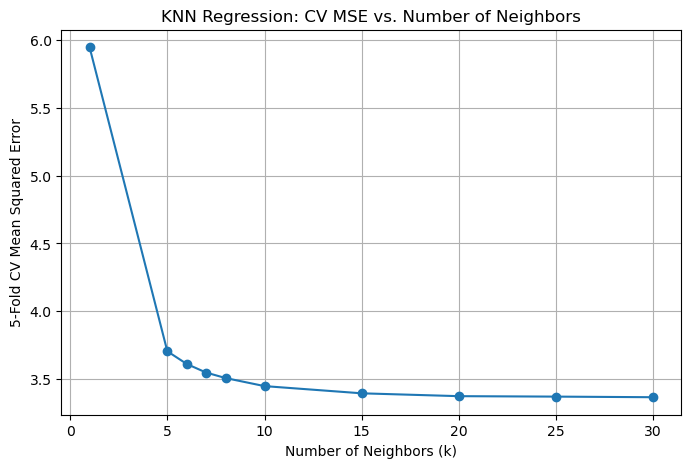

In [8]:
from sklearn.model_selection import cross_val_score

# Define candidate k values
k_values = [1, 5, 6, 7, 8, 10, 15, 20, 25, 30]
cv_mse = []

# Loop through each k value and perform 5-fold cross-validation on the training set
for k in k_values:
    knn_reg_cv = KNeighborsRegressor(n_neighbors=k, metric='minkowski', p=2)
    # Use negative MSE as the scoring metric (scikit-learn returns negative values for errors)
    scores = cross_val_score(knn_reg_cv, X_train, y_train, cv=5, scoring='neg_mean_squared_error')
    # Convert negative MSE to positive and compute the mean
    mean_mse = np.mean(-scores)
    cv_mse.append(mean_mse)
    print(f"k = {k} => CV Mean Squared Error: {mean_mse:.4f}")

# Plot the CV MSE versus k values
plt.figure(figsize=(8,5))
plt.plot(k_values, cv_mse, marker='o', linestyle='-')
plt.xlabel("Number of Neighbors (k)")
plt.ylabel("5-Fold CV Mean Squared Error")
plt.title("KNN Regression: CV MSE vs. Number of Neighbors")
plt.grid(True)
plt.show()


### 6. Visualise performance metrics using bar plots

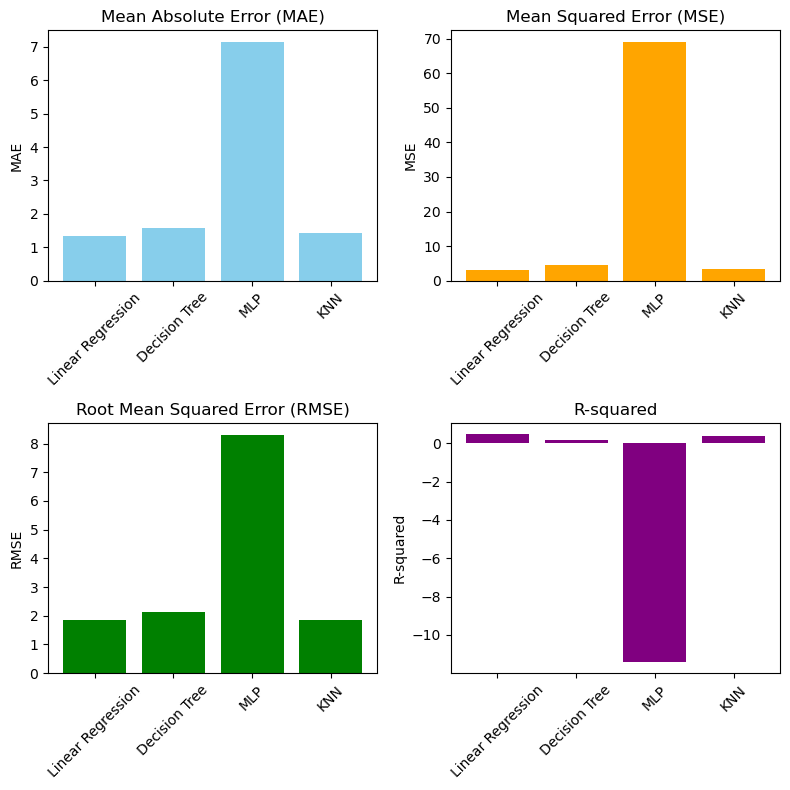

In [6]:
# Metrics for each model
models = ['Linear Regression', 'Decision Tree', 'MLP', 'KNN']
mae_values = [mae, mae_dt, mae_nn, mae_knn]
mse_values = [mse, mse_dt, mse_nn, mse_knn]
rmse_values = [rmse, rmse_dt, rmse_nn, rmse]
r2_values = [r2, r2_dt, r2_nn, r2_knn]

# Plotting
x = np.arange(len(models))  # the label locations
width = 0.8  # the width of the bars

fig, ax = plt.subplots(2, 2, figsize=(8, 8))

# MAE
ax[0, 0].bar(x, mae_values, width, color='skyblue')
ax[0, 0].set_title('Mean Absolute Error (MAE)')
ax[0, 0].set_xticks(x)
ax[0, 0].set_xticklabels(models, rotation=45)
ax[0, 0].set_ylabel('MAE')

# MSE
ax[0, 1].bar(x, mse_values, width, color='orange')
ax[0, 1].set_title('Mean Squared Error (MSE)')
ax[0, 1].set_xticks(x)
ax[0, 1].set_xticklabels(models, rotation=45)
ax[0, 1].set_ylabel('MSE')

# RMSE
ax[1, 0].bar(x, rmse_values, width, color='green')
ax[1, 0].set_title('Root Mean Squared Error (RMSE)')
ax[1, 0].set_xticks(x)
ax[1, 0].set_xticklabels(models, rotation=45)
ax[1, 0].set_ylabel('RMSE')

# R-squared
ax[1, 1].bar(x, r2_values, width, color='purple')
ax[1, 1].set_title('R-squared')
ax[1, 1].set_xticks(x)
ax[1, 1].set_xticklabels(models, rotation=45)
ax[1, 1].set_ylabel('R-squared')

# Adjust layout
plt.tight_layout()
plt.show()

As shown in the diagram and statistics above, Linear Regression has least errors in MAE, MSE and RMSE. It also has the highest R-squared value which means it is able to capture the variation in the data the best amongst the 4 models.

### 7. Visualisation on Linear Regression values

As Linear Regression seem to be the best model out of the 4, we create more visualisations to further illustrate the performance of Linear Regression.

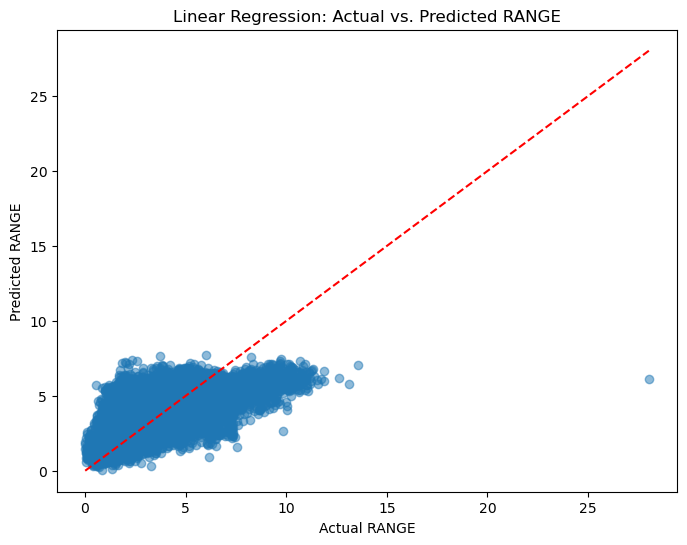

In [7]:
# Plot Actual vs. Predicted values
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.xlabel("Actual RANGE")
plt.ylabel("Predicted RANGE")
plt.title("Linear Regression: Actual vs. Predicted RANGE")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.show()

### 8. Feature Importance on Coefficients visualisation

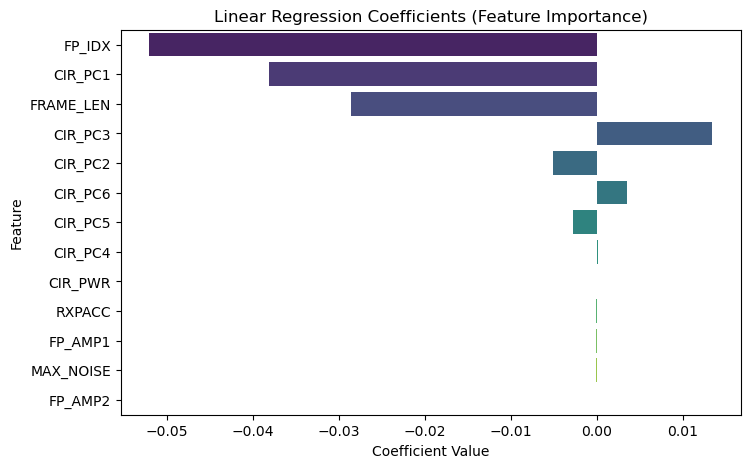

In [8]:
X_train_no_range = X_train 

# Extract coefficients from the linear regression model
coefficients = pd.Series(linreg.coef_, index=X_train_no_range.columns)
# Sort coefficients by absolute value (largest impact first)
coefficients_sorted = coefficients.reindex(coefficients.abs().sort_values(ascending=False).index)

plt.figure(figsize=(8,5))
ax = sns.barplot(x=coefficients_sorted.values,
                 y=coefficients_sorted.index,
                 hue=coefficients_sorted.index,
                 palette="viridis",
                 dodge=False)
if ax.get_legend() is not None:
    ax.get_legend().remove()

plt.xlabel("Coefficient Value")
plt.ylabel("Feature")
plt.title("Linear Regression Coefficients (Feature Importance)")
plt.show()

### 9. Permutation Importance visualisation

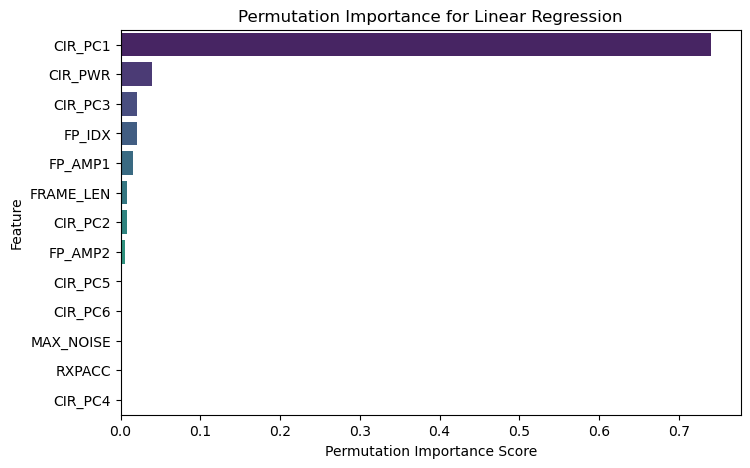

In [9]:
from sklearn.inspection import permutation_importance

X_test_no_range = X_test

r = permutation_importance(linreg, X_test_no_range, y_test, n_repeats=10, random_state=111)
perm_importances = pd.Series(r.importances_mean, index=X_test_no_range.columns).sort_values(ascending=False)

plt.figure(figsize=(8,5))
ax = sns.barplot(x=perm_importances.values, 
                 y=perm_importances.index, 
                 hue=perm_importances.index, 
                 palette="viridis", 
                 dodge=False)
if ax.get_legend() is not None:
    ax.get_legend().remove()

plt.xlabel("Permutation Importance Score")
plt.ylabel("Feature")
plt.title("Permutation Importance for Linear Regression")
plt.show()